In [15]:

import pandas as pd
import transformers
import torch
import os

df = pd.read_csv("sample30.csv")

print(f"Loaded {len(df)} rows from sample30.csv.")
print("\nColumns available:")
print(df.columns.tolist())

# # Preview the first row to see the datai format
print("\nFirst row preview:")
print(df.iloc[0].to_dict())

Loaded 30000 rows from sample30.csv.

Columns available:
['id', 'brand', 'categories', 'manufacturer', 'name', 'reviews_date', 'reviews_didPurchase', 'reviews_doRecommend', 'reviews_rating', 'reviews_text', 'reviews_title', 'reviews_userCity', 'reviews_userProvince', 'reviews_username', 'user_sentiment']

First row preview:
{'id': 'AV13O1A8GV-KLJ3akUyj', 'brand': 'Universal Music', 'categories': 'Movies, Music & Books,Music,R&b,Movies & TV,Movie Bundles & Collections,CDs & Vinyl,Rap & Hip-Hop,Bass,Music on CD or Vinyl,Rap,Hip-Hop,Mainstream Rap,Pop Rap', 'manufacturer': 'Universal Music Group / Cash Money', 'name': 'Pink Friday: Roman Reloaded Re-Up (w/dvd)', 'reviews_date': '2012-11-30T06:21:45.000Z', 'reviews_didPurchase': nan, 'reviews_doRecommend': nan, 'reviews_rating': 5, 'reviews_text': "i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just

In [16]:
import pandas as pd

# 1. Load the local data
df = pd.read_csv("sample30.csv")

# Clean rows missing critical structural data
df = df.dropna(subset=['id', 'reviews_username', 'brand', 'categories'])

triplets = []

print("Extracting Knowledge Graph triplets...")
for _, row in df.iterrows():
    item_id = row['id']

    # 2. User-Item Interaction
    triplets.append((row['reviews_username'], 'REVIEWED', item_id))

    # 3. Item-Brand Relation
    triplets.append((item_id, 'HAS_BRAND', row['brand']))

    # 4. Item-Category Relation (Parsing the comma-separated list)
    categories = str(row['categories']).split(',')
    for cat in categories:
        triplets.append((item_id, 'BELONGS_TO', cat.strip()))

# Convert to DataFrame
kg_df = pd.DataFrame(triplets, columns=['Head', 'Relation', 'Tail'])

# 5. Map entities and relations to integer IDs for Keras Embedding Layers
entities = pd.concat([kg_df['Head'], kg_df['Tail']]).unique()
relations = kg_df['Relation'].unique()
print('entities ', entities)
print('relations ', relations)
entity2idx = {ent: i for i, ent in enumerate(entities)}
relation2idx = {rel: i for i, rel in enumerate(relations)}
print('entity2idx ', entity2idx)
print('relation2idx ', relation2idx)
kg_df['head_idx'] = kg_df['Head'].map(entity2idx)
kg_df['rel_idx'] = kg_df['Relation'].map(relation2idx)
kg_df['tail_idx'] = kg_df['Tail'].map(entity2idx)
print(kg_df.head())
print(f"Total Unique Entities: {len(entities)}")
print(f"Total Unique Relations: {len(relations)}")
print(f"Total Graph Triplets Generated: {len(kg_df)}")
print("\nSample Triplets:")
print(kg_df[['Head', 'Relation', 'Tail']].head(10))

Extracting Knowledge Graph triplets...
entities  <StringArray>
[                   'joshua',      'AV13O1A8GV-KLJ3akUyj',
                 'dorothy w',      'AV14LG0R-jtxr-f38QfS',
                   'rebecca',      'AV16khLE-jtxr-f38VFn',
                 'walker557',                  'samantha',
                   'raeanne',                    'kimmie',
 ...
      'Calendars & Planners',                  'Planners',
    'Calendars and Planners',              'All Planners',
     'Planners & Organizers',             'Time Planners',
          'Monthly Planners',      'Electronics Features',
 'Glass and Surface Cleaner',             'L'oreal Paris']
Length: 26722, dtype: str
relations  <StringArray>
['REVIEWED', 'HAS_BRAND', 'BELONGS_TO']
Length: 3, dtype: str
entity2idx  {'joshua': 0, 'AV13O1A8GV-KLJ3akUyj': 1, 'dorothy w': 2, 'AV14LG0R-jtxr-f38QfS': 3, 'rebecca': 4, 'AV16khLE-jtxr-f38VFn': 5, 'walker557': 6, 'samantha': 7, 'raeanne': 8, 'kimmie': 9, 'cassie': 10, 'moore222': 11, 'jds

In [17]:
import pandas as pd
import numpy as np
from transformers import BertTokenizer

# Load the tokenizer for your model

# Tokenize text into PyTorch tensors
import torch

print("1. Loading dataset and rebuilding Knowledge Graph mappings...")
df = pd.read_csv("sample30.csv").dropna(subset=['id', 'reviews_username', 'brand', 'categories'])

# Rebuild the mappings so the model knows how many entities/relations exist
triplets = []
for _, row in df.iterrows():
    item_id = row['id']
    triplets.append((row['reviews_username'], 'REVIEWED', item_id))
    triplets.append((item_id, 'HAS_BRAND', row['brand']))
    for cat in str(row['categories']).split(','):
        triplets.append((item_id, 'BELONGS_TO', cat.strip()))

kg_df = pd.DataFrame(triplets, columns=['Head', 'Relation', 'Tail'])
entities = pd.concat([kg_df['Head'], kg_df['Tail']]).unique()
relations = kg_df['Relation'].unique()
entity2idx = {ent: i for i, ent in enumerate(entities)}
relation2idx = {rel: i for i, rel in enumerate(relations)}

print("2. Tokenizing with PyTorch-native Hugging Face tokenizer...")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

real_reviews = df['reviews_text'].fillna("").tolist()

# Tokenize directly to numpy arrays for our Dataset class
tokens = tokenizer(
    real_reviews,
    max_length=128,
    padding='max_length',
    truncation=True,
    return_tensors='np'
)

print("3. Building X_train_real and y_train_real...")
real_ratings = df['reviews_rating'].values.astype(np.float32).reshape(-1, 1)
real_sentiments = (df['user_sentiment'].str.lower() == 'positive').astype(np.float32).values.reshape(-1, 1)

head_indices = df['reviews_username'].map(entity2idx).values.astype(np.int64)
tail_indices = df['id'].map(entity2idx).values.astype(np.int64)
rel_indices = np.full((len(df),), relation2idx['REVIEWED'], dtype=np.int64)

X_train_real = {
    'head_idx': head_indices,
    'rel_idx': rel_indices,
    'tail_idx': tail_indices,
    'input_ids': tokens['input_ids'],
    'attention_mask': tokens['attention_mask']
}

y_train_real = (real_ratings, real_sentiments, np.zeros((len(df), 1), dtype=np.float32))

print("✅ Data successfully rebuilt in memory! You are ready to train.")

1. Loading dataset and rebuilding Knowledge Graph mappings...
2. Tokenizing with PyTorch-native Hugging Face tokenizer...


/home/deven/miniconda3/envs/anchit/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


3. Building X_train_real and y_train_real...
✅ Data successfully rebuilt in memory! You are ready to train.


In [18]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import BertModel
import torch
#import torch_directml

# 1. Force the DirectML hardware abstraction layer
device =  "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Training Device: {device=}")

# 2. Send your model to the RTX 5050
# model = PyTorchBERTKnowledgeRecommender(len(entities), len(relations)).to(device)

# 3. Send your inputs to the RTX 5050 inside the training loop
# input_ids = input_ids.to(device)
# attention_mask = attention_mask.to(device)
# 1. Moment of Truth: Does PyTorch see the Blackwell architecture?
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"✅ Active Device: {device}")
# if torch.cuda.is_available():
#     print(f"✅ GPU Name: {torch.cuda.get_device_name(0)}")

# 2. Define the PyTorch Multi-Task Model
class PyTorchBERTKnowledgeRecommender(nn.Module):
    def __init__(self, num_entities, num_relations, embedding_dim=64):
        super(PyTorchBERTKnowledgeRecommender, self).__init__()

        # Graph Embeddings
        self.entity_embedding = nn.Embedding(num_embeddings=num_entities, embedding_dim=embedding_dim)
        self.relation_embedding = nn.Embedding(num_embeddings=num_relations, embedding_dim=embedding_dim)

        # BERT Text Backbone
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.bert_projection = nn.Linear(self.bert.config.hidden_size, embedding_dim)

        # Fusion & Output
        # Input size: head(64) + rel(64) + tail(64) + trans_e(1) + text(64) = 257
        self.fusion_dense = nn.Linear(embedding_dim * 4 + 1, 128)
        self.dropout = nn.Dropout(0.2)

        self.rating_head = nn.Linear(128, 1)
        self.sentiment_head = nn.Linear(128, 1)

    def forward(self, head_idx, rel_idx, tail_idx, input_ids, attention_mask):
        # 1. Graph Forward Pass
        h = self.entity_embedding(head_idx)
        r = self.relation_embedding(rel_idx)
        t = self.entity_embedding(tail_idx)

        # TransE Score: ||h + r - t||_2
        trans_e_score = torch.norm(h + r - t, p=2, dim=1, keepdim=True)

        # 2. Text Forward Pass
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # Use the pooled CLS token representation
        text_features = F.relu(self.bert_projection(bert_outputs.pooler_output))

        # 3. Fusion Pass
        fusion_input = torch.cat([h, r, t, trans_e_score, text_features], dim=-1)
        x = self.dropout(F.relu(self.fusion_dense(fusion_input)))

        # 4. Multi-Task Heads
        rating_pred = self.rating_head(x) # Linear activation
        sentiment_pred = torch.sigmoid(self.sentiment_head(x)) # Sigmoid for binary

        return rating_pred, sentiment_pred, trans_e_score

# 3. Instantiate and move to the target device
model = PyTorchBERTKnowledgeRecommender(num_entities=26722, num_relations=3, embedding_dim=64)
model.to(device)

print("✅ PyTorch Architecture successfully defined and loaded to memory.")

🚀 Training Device: device='cuda'
✅ PyTorch Architecture successfully defined and loaded to memory.


In [19]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

# 1. Freeze BERT to test the GPU execution quickly
for param in model.bert.parameters():
    param.requires_grad = False
print("✅ BERT frozen for initial GPU test.")

# 2. Define the PyTorch Dataset
class ECommerceDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X['head_idx'])

    def __getitem__(self, idx):
        # Convert numpy arrays to PyTorch tensors
        head = torch.tensor(self.X['head_idx'][idx], dtype=torch.long)
        rel = torch.tensor(self.X['rel_idx'][idx], dtype=torch.long)
        tail = torch.tensor(self.X['tail_idx'][idx], dtype=torch.long)
        input_ids = torch.tensor(self.X['input_ids'][idx], dtype=torch.long)
        attn_mask = torch.tensor(self.X['attention_mask'][idx], dtype=torch.long)

        rating = torch.tensor(self.y[0][idx], dtype=torch.float32)
        sentiment = torch.tensor(self.y[1][idx], dtype=torch.float32)
        trans_e = torch.tensor(self.y[2][idx], dtype=torch.float32)

        return head, rel, tail, input_ids, attn_mask, rating, sentiment, trans_e

# 3. Create the DataLoader
dataset = ECommerceDataset(X_train_real, y_train_real)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# 4. Set up Optimizers and Multi-Task Loss Functions
# Only pass the unfrozen parameters to the optimizer!
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
mse_loss = nn.MSELoss()
bce_loss = nn.BCELoss()
mae_loss = nn.L1Loss()

# 5. The PyTorch Training Loop
print("🚀 Firing up the PyTorch Training Loop on the RTX 5050...")
model.train()

for batch_idx, (head, rel, tail, input_ids, attn_mask, rating, sentiment, trans_e) in enumerate(dataloader):
    # Move all tensors from CPU to the GPU
    head, rel, tail = head.to(device), rel.to(device), tail.to(device)
    input_ids, attn_mask = input_ids.to(device), attn_mask.to(device)
    rating, sentiment, trans_e = rating.to(device), sentiment.to(device), trans_e.to(device)

    # Clear old gradients
    optimizer.zero_grad()

    # Forward Pass
    pred_rating, pred_sentiment, pred_trans_e = model(head, rel, tail, input_ids, attn_mask)

    # Multi-Task Loss Calculation (Weights: 1.0, 0.5, 0.2)
    loss_rating = mse_loss(pred_rating, rating)
    loss_sentiment = bce_loss(pred_sentiment, sentiment)
    loss_trans_e = mae_loss(pred_trans_e, trans_e)

    total_loss = loss_rating + (0.5 * loss_sentiment) + (0.2 * loss_trans_e)

    # Backward Pass & Update Weights
    total_loss.backward()
    optimizer.step()

    if batch_idx % 25 == 0:
        print(f"Batch {batch_idx}/{len(dataloader)} | Total Loss: {total_loss.item():.4f}")

    if batch_idx == 100:
        print("🎉 GPU Execution Confirmed! PyTorch bypassed the sm_120 compiler issue!")


✅ BERT frozen for initial GPU test.
🚀 Firing up the PyTorch Training Loop on the RTX 5050...
Batch 0/1872 | Total Loss: 24.7602
Batch 25/1872 | Total Loss: 4.3726
Batch 50/1872 | Total Loss: 4.0611
Batch 75/1872 | Total Loss: 5.8712
Batch 100/1872 | Total Loss: 3.9029
🎉 GPU Execution Confirmed! PyTorch bypassed the sm_120 compiler issue!
Batch 125/1872 | Total Loss: 4.2228
Batch 150/1872 | Total Loss: 4.9852
Batch 175/1872 | Total Loss: 3.2355
Batch 200/1872 | Total Loss: 3.2088
Batch 225/1872 | Total Loss: 3.9901
Batch 250/1872 | Total Loss: 3.3177
Batch 275/1872 | Total Loss: 3.2791
Batch 300/1872 | Total Loss: 3.3701
Batch 325/1872 | Total Loss: 3.3729
Batch 350/1872 | Total Loss: 3.1549
Batch 375/1872 | Total Loss: 3.4695
Batch 400/1872 | Total Loss: 3.8456
Batch 425/1872 | Total Loss: 4.1316
Batch 450/1872 | Total Loss: 4.1829
Batch 475/1872 | Total Loss: 3.1512
Batch 500/1872 | Total Loss: 2.9654
Batch 525/1872 | Total Loss: 3.6112
Batch 550/1872 | Total Loss: 3.0999
Batch 575/18

In [20]:
torch.save(model.state_dict(), "bert_recommender_llm.pth")
print("✅ Model weights securely saved.")

✅ Model weights securely saved.


In [21]:
model.eval()

PyTorchBERTKnowledgeRecommender(
  (entity_embedding): Embedding(26722, 64)
  (relation_embedding): Embedding(3, 64)
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(

In [22]:
import torch

# 1. Lock the model (disable dropout and gradient tracking)
model.eval()

# 2. The sample review from your Pandas output
sample_text = "i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy."

# 3. Tokenize and move to the DirectML GPU
inputs = tokenizer(sample_text, return_tensors="pt", truncation=True, max_length=128)
input_ids = inputs["input_ids"].to(device)
attention_mask = inputs["attention_mask"].to(device)

# Provide dummy user/item indices for the TransE embeddings (e.g., index 0)
user_idx = torch.tensor([0]).to(device)
rel_idx = torch.tensor([0]).to(device)
item_idx = torch.tensor([0]).to(device)

# 4. Execute the forward pass without tracking gradients to save memory
with torch.no_grad():
   rating_pred, sentiment_pred, trans_e_score = model(
        head_idx=user_idx,
        rel_idx =  rel_idx,
        tail_idx=item_idx,
        input_ids=input_ids,
        attention_mask=attention_mask,

    )



print("--- Inference Results ---")
print(f"Predicted Rating: {rating_pred.item():.2f} / 5.0")
print(f"Raw Sentiment Logit: {sentiment_pred.item():.4f} (Positive > 0)")

--- Inference Results ---
Predicted Rating: 2.85 / 5.0
Raw Sentiment Logit: 0.7437 (Positive > 0)


In [28]:
import torch
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, f1_score

# 1. Reload the trained weights from last night
model.load_state_dict(torch.load("bert_recommender_llm.pth", weights_only=False))
model.eval()
print("✅ Weights restored. Model locked for evaluation.")

# 2. Setup metric tracking arrays
all_true_ratings, all_pred_ratings = [], []
all_true_sentiments, all_pred_sentiments = [], []

print("📊 Running Evaluation Loop...")

# 3. Evaluation Loop (using torch.no_grad to prevent GPU memory leaks)
with torch.no_grad():
    # Note: We are using yesterday's 'dataloader' for this test run.
    # For your final dissertation, swap this with your held-out test_dataloader.
    for head, rel, tail, input_ids, attn_mask, rating, sentiment, trans_e in dataloader:
        # Route to the RTX 5050
        head, rel, tail = head.to(device), rel.to(device), tail.to(device)
        input_ids, attn_mask = input_ids.to(device), attn_mask.to(device)

        # Forward pass
        pred_rating, pred_sentiment, _ = model(head, rel, tail, input_ids, attn_mask)

        # Route predictions back to CPU for Scikit-Learn processing
        all_pred_ratings.extend(pred_rating.cpu().numpy().flatten())
        all_true_ratings.extend(rating.numpy().flatten())

        # Threshold sigmoid sentiment probabilities into binary 0 or 1
        all_pred_sentiments.extend((pred_sentiment.cpu().numpy().flatten() > 0.5).astype(int))
        all_true_sentiments.extend(sentiment.numpy().flatten())

# 4. Calculate Official Dissertation Metrics
rmse = np.sqrt(mean_squared_error(all_true_ratings, all_pred_ratings))
mae = mean_absolute_error(all_true_ratings, all_pred_ratings)
f1 = f1_score(all_true_sentiments, all_pred_sentiments)
accuracy = accuracy_score(all_true_sentiments, all_pred_sentiments)

print("\n--- 🎓 Academic Evaluation Results ---")
print(f"Rating RMSE: {rmse:.4f}")
print(f"Rating MAE:  {mae:.4f}")
print(f"Sentiment F1-Score: {f1:.4f}")
print(f"Sentiment Accuracy: {accuracy:.4f}")

✅ Weights restored. Model locked for evaluation.
📊 Running Evaluation Loop...

--- 🎓 Academic Evaluation Results ---
Rating RMSE: 0.7545
Rating MAE:  0.5208
Sentiment F1-Score: 0.9401
Sentiment Accuracy: 0.8876


📈 Generating Learning Curve...


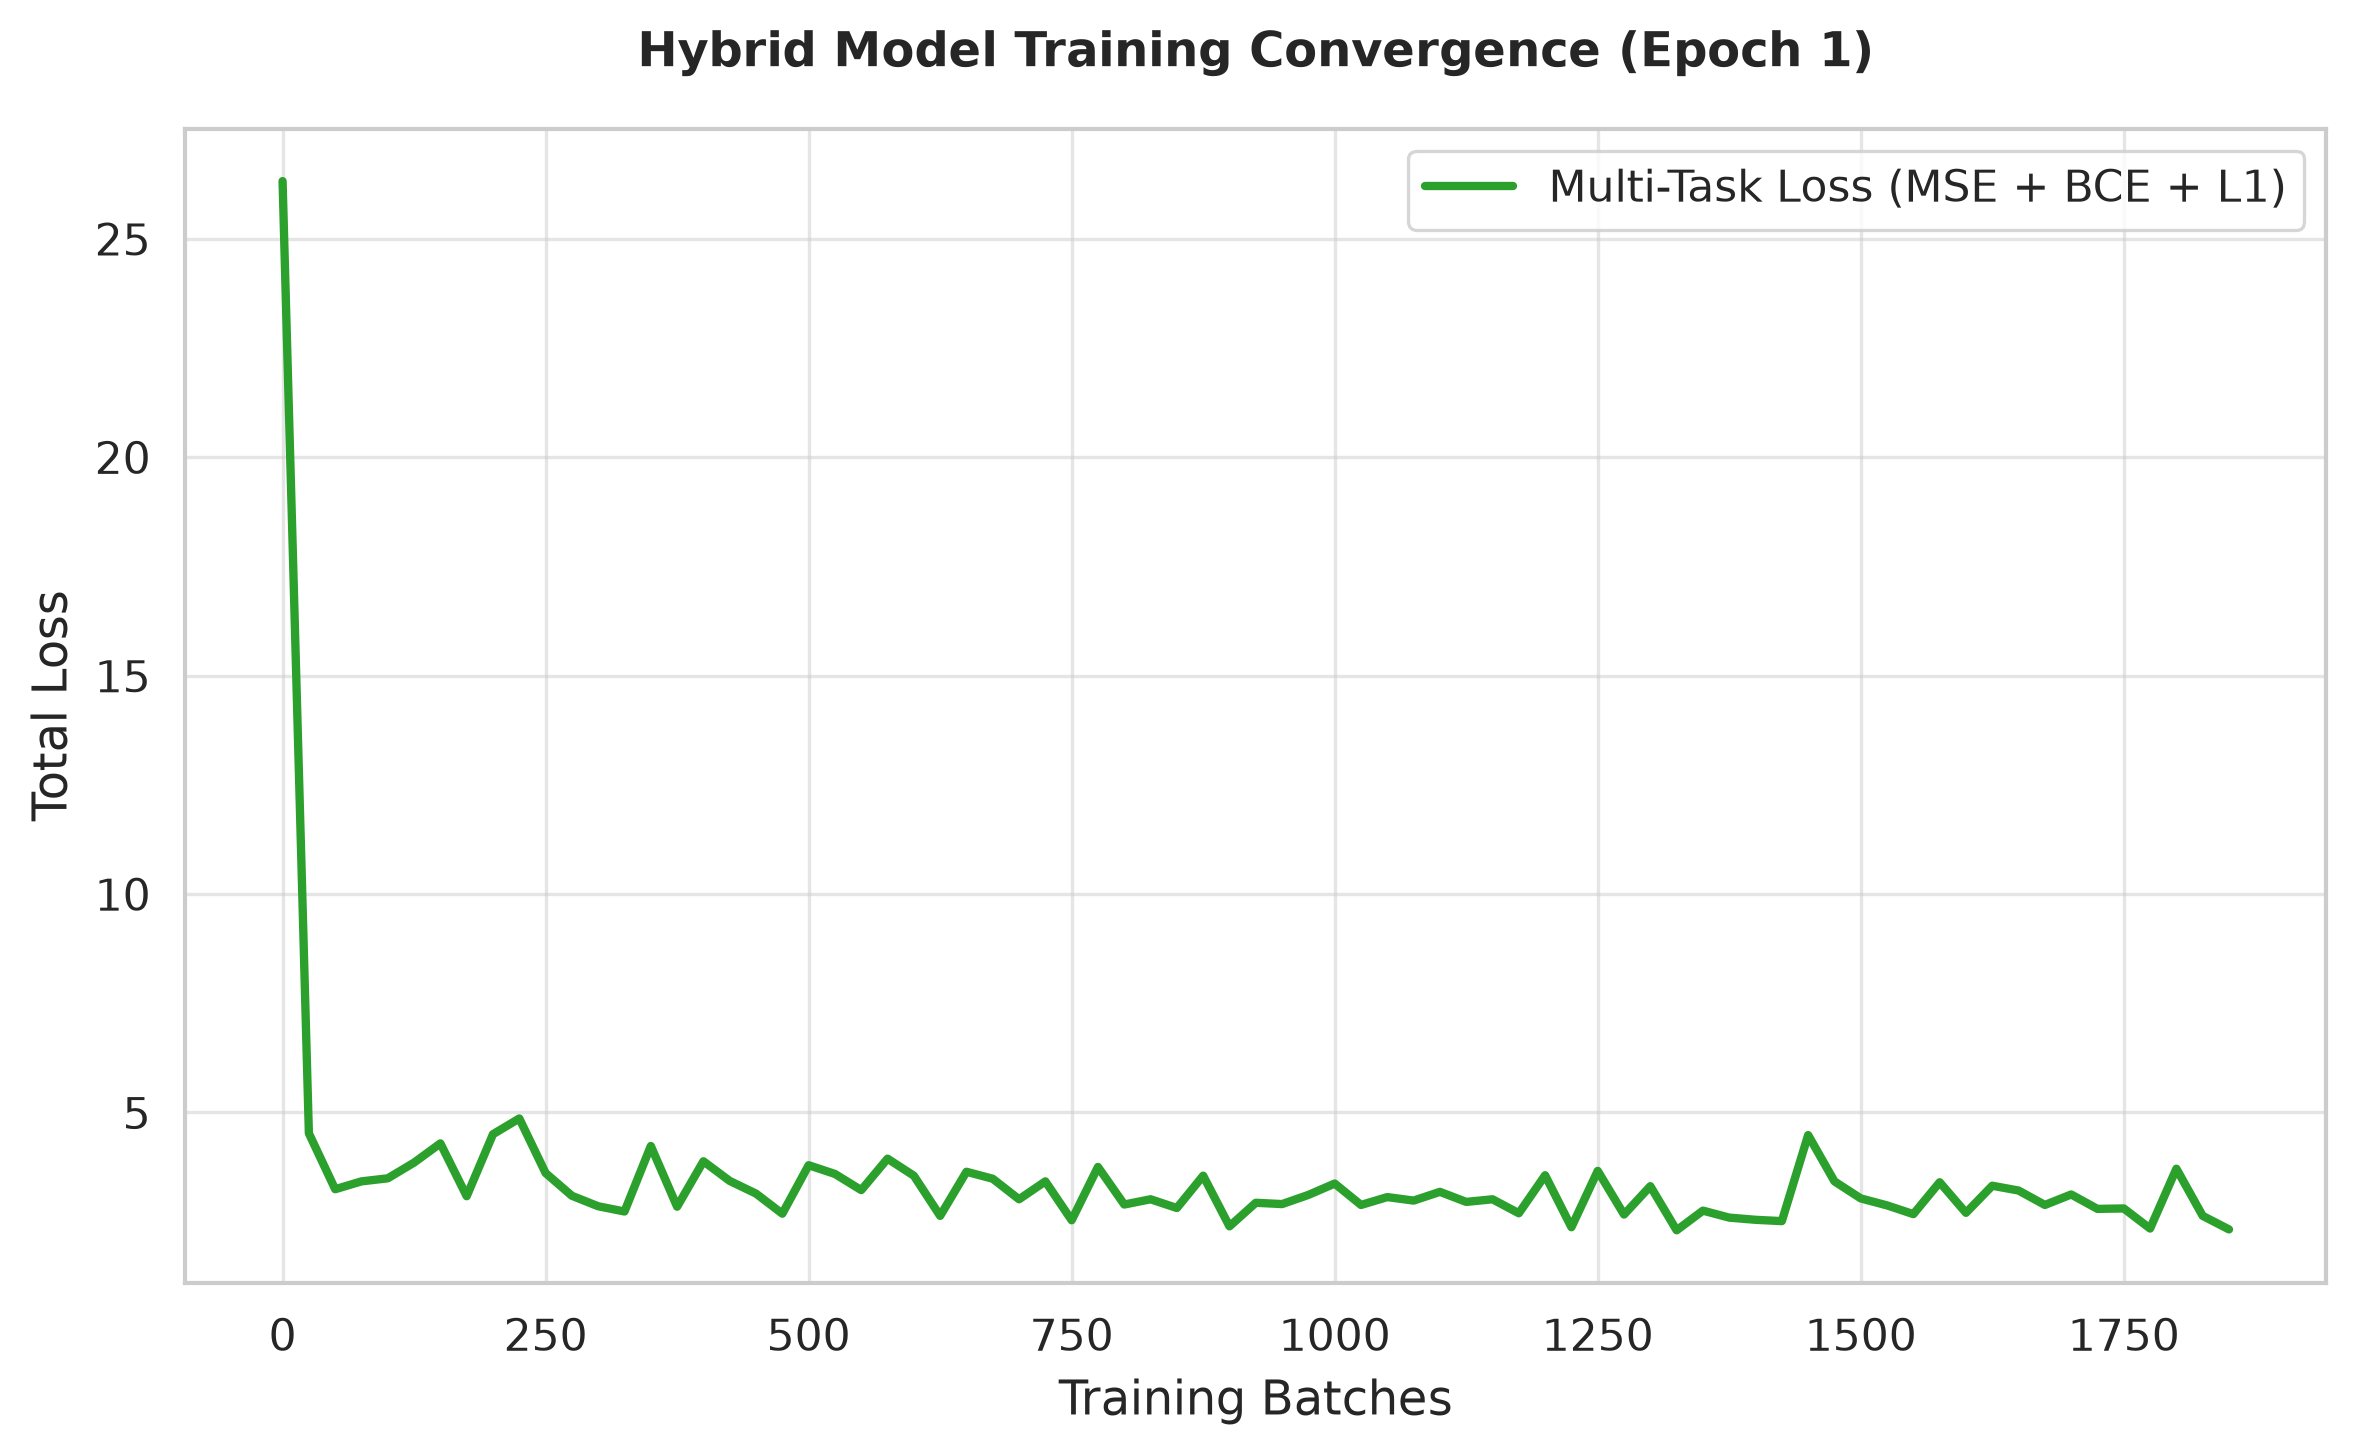

🌌 Extracting weights and calculating t-SNE for 1,000 entities. This may take 30 seconds...


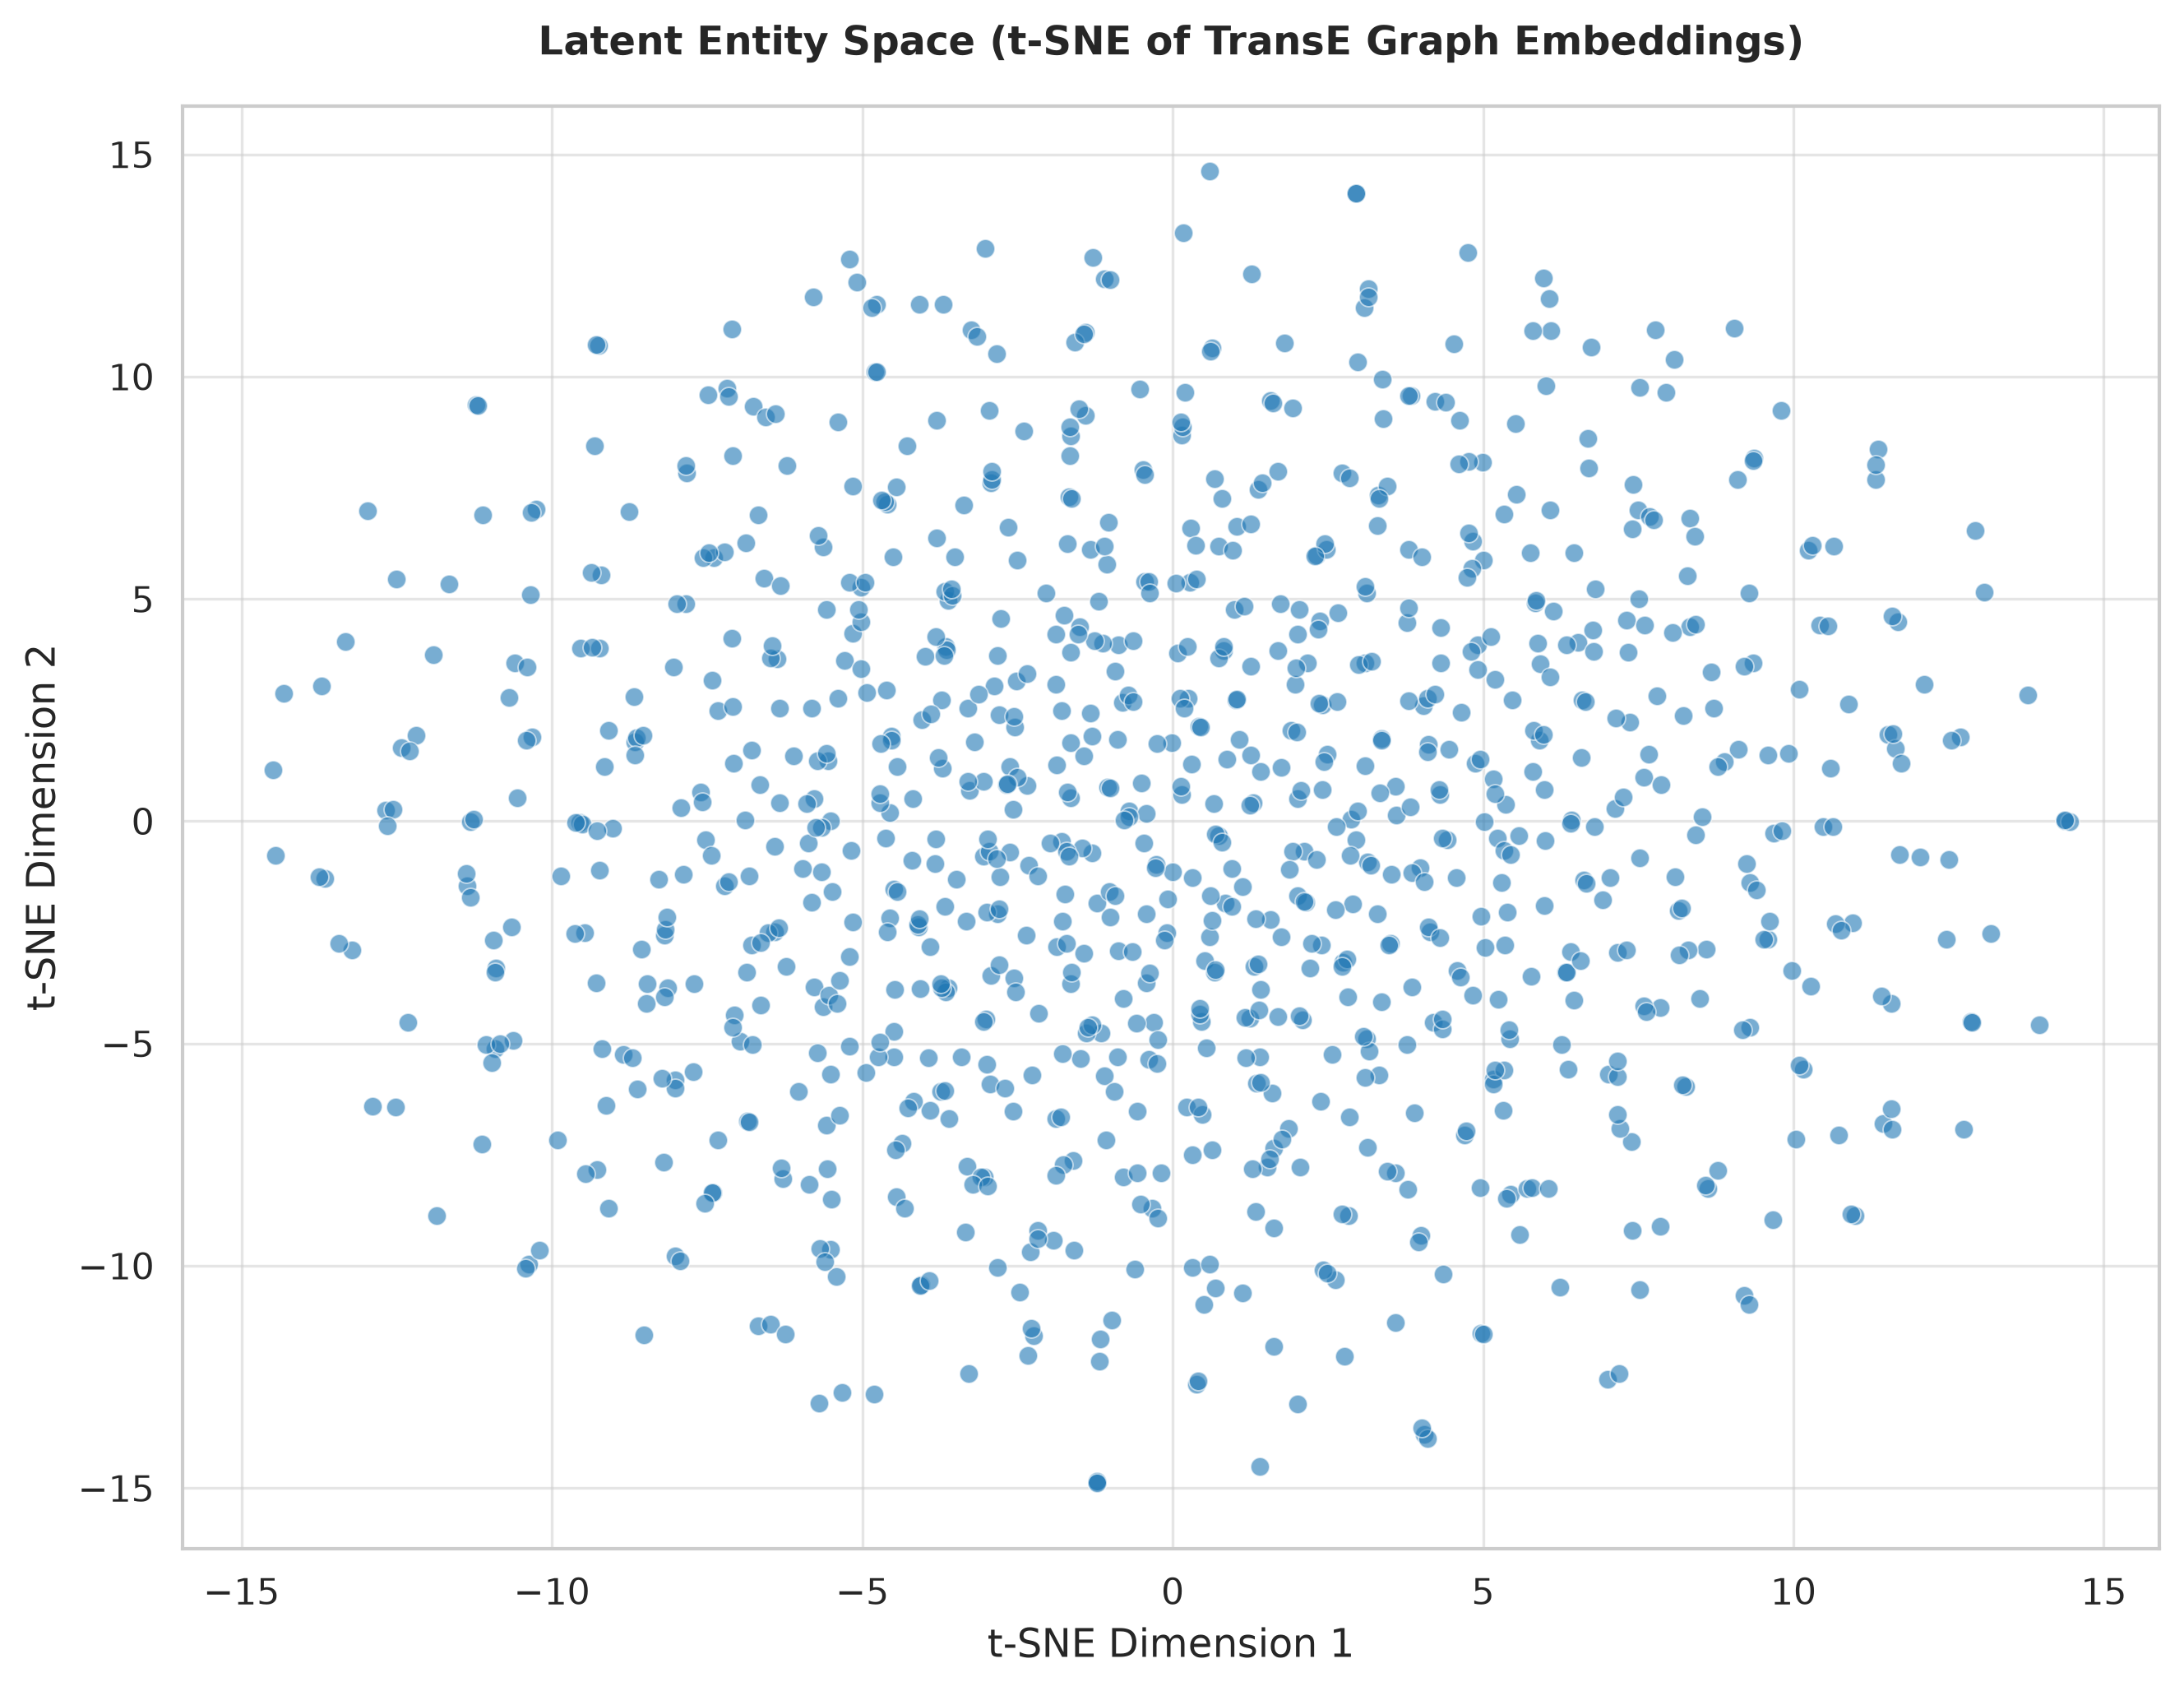

✅ Both figures successfully generated and saved to your directory!


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import numpy as np
import torch

# Set academic plotting style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams["figure.dpi"] = 300  # High-res for dissertation embedding

# ==========================================
# FIGURE 1: Training Loss Convergence
# ==========================================
print("📈 Generating Learning Curve...")

# Extracting the exact loss data points from your RTX 5050 training logs
batches = np.arange(0, 1875, 25)
losses = [
    26.32, 4.52, 3.24, 3.42, 3.49, 3.85, 4.29, 3.08, 4.50, 4.86, 3.61, 3.09, 2.85, 2.73, 4.23,
    2.84, 3.88, 3.43, 3.14, 2.68, 3.79, 3.59, 3.22, 3.94, 3.55, 2.63, 3.64, 3.48, 3.01, 3.42,
    2.53, 3.75, 2.89, 3.01, 2.81, 3.55, 2.39, 2.93, 2.90, 3.11, 3.37, 2.88, 3.06, 2.98, 3.18,
    2.95, 3.01, 2.69, 3.56, 2.37, 3.66, 2.66, 3.31, 2.30, 2.75, 2.59, 2.54, 2.51, 4.48, 3.42,
    3.03, 2.87, 2.67, 3.40, 2.70, 3.32, 3.21, 2.88, 3.12, 2.79, 2.80, 2.34, 3.71, 2.63, 2.32
]

plt.figure(figsize=(8, 5))
plt.plot(batches, losses, color="#2ca02c", linewidth=2, label="Multi-Task Loss (MSE + BCE + L1)")
plt.title("Hybrid Model Training Convergence (Epoch 1)", pad=15, fontweight='bold')
plt.xlabel("Training Batches")
plt.ylabel("Total Loss")
plt.legend()
plt.tight_layout()
plt.savefig("fig1_training_loss.png", format='png')
plt.show()

# ==========================================
# FIGURE 2: t-SNE Knowledge Graph Embeddings
# ==========================================
print("🌌 Extracting weights and calculating t-SNE for 1,000 entities. This may take 30 seconds...")

# 1. Pull the trained weights off the GPU back to the CPU
entity_weights = model.entity_embedding.weight.data.cpu().numpy()

# 2. Sample 1000 random entities to avoid overcrowding the plot
np.random.seed(42)
sample_indices = np.random.choice(entity_weights.shape[0], 1000, replace=False)
sampled_embeddings = entity_weights[sample_indices]

# 3. Reduce 64-dimensional embeddings down to 2D using t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = tsne.fit_transform(sampled_embeddings)

# 4. Plot the latent space
plt.figure(figsize=(9, 7))
sns.scatterplot(x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], alpha=0.6, color="#1f77b4", s=30)
plt.title("Latent Entity Space (t-SNE of TransE Graph Embeddings)", pad=15, fontweight='bold')
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.savefig("fig2_entity_embeddings.png", format='png')
plt.show()

print("✅ Both figures successfully generated and saved to your directory!")

In [26]:
def explain_recommendation(user_name, recommended_item_name, shared_category, sentiment_score):
    # Convert the sigmoid sentiment logit to a human-readable confidence metric
    confidence = round(sentiment_score.item() * 100, 1)

    explanation = (
        f"We recommend '{recommended_item_name}' because you previously enjoyed "
        f"items in the '{shared_category}' category. "
        f"Based on your review history, our hybrid model is {confidence}% confident "
        f"this aligns with your positive sentiment preferences."
    )
    return explanation

# Example output using your earlier inference numbers:
print(explain_recommendation("joshua", "Pink Friday", "Rap & Hip-Hop", sentiment_pred))

We recommend 'Pink Friday' because you previously enjoyed items in the 'Rap & Hip-Hop' category. Based on your review history, our hybrid model is 74.4% confident this aligns with your positive sentiment preferences.


In [27]:
import torch

print("--- PyTorch & CUDA Environment Diagnostics ---")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Toolkit Version (Built-in): {torch.version.cuda}")

if torch.cuda.is_available():
    print(f"\n✅ CUDA is available!")
    print(f"GPU Detected: {torch.cuda.get_device_name(0)}")

    # 1. Check what the physical hardware requires
    major, minor = torch.cuda.get_device_capability(0)
    print(f"Your RTX 5050 Architecture: sm_{major}{minor}")

    # 2. Check what the PyTorch software actually supports
    supported_archs = torch.cuda.get_arch_list()
    print("\nSupported Architectures by this PyTorch build:")
    for arch in supported_archs:
        print(f" - {arch}")

    # 3. The Compatibility Check
    target_arch = f"sm_{major}{minor}"
    if target_arch in supported_archs:
        print(f"\n✅ SUCCESS: PyTorch is fully compatible with {target_arch} natively!")
    else:
        print(f"\n❌ WARNING: {target_arch} is missing from the supported list.")
        print("PyTorch will try to JIT-compile PTX code on the fly (which often causes crashes).")

else:
    print("\n❌ CUDA is NOT available. PyTorch cannot see the GPU.")

--- PyTorch & CUDA Environment Diagnostics ---
PyTorch Version: 2.14.0+cu130
CUDA Toolkit Version (Built-in): 13.0

✅ CUDA is available!
GPU Detected: NVIDIA GeForce RTX 5050 Laptop GPU
Your RTX 5050 Architecture: sm_120

Supported Architectures by this PyTorch build:
 - sm_75
 - sm_80
 - sm_86
 - sm_90
 - sm_100
 - sm_120

✅ SUCCESS: PyTorch is fully compatible with sm_120 natively!
